In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19, MobileNetV2, Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score

In [2]:
path = "F:/Office/Project2026/PlantDiseaseTransformer/"
train_dir = path+"Dataset/train"
test_dir = path+"Dataset/test"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 10

In [4]:
#Data Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(num_classes)

Found 4745 images belonging to 4 classes.
Found 595 images belonging to 4 classes.
4


In [6]:
#Model Builder Function
def build_model(base_model):

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
#Train MobileNetV2 Model
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_mobilenet.layers:
    layer.trainable = False

model_mobilenet = build_model(base_mobilenet)

history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)

model_mobilenet.save(path+"model/MobileNetV2_rice_disease.h5")



Epoch 1/10


149/149 [==============================] - 309s 2s/step - loss: 0.8673 - accuracy: 0.6523 - val_loss: 0.3783 - val_accuracy: 0.8756
Epoch 2/10
149/149 [==============================] - 497s 3s/step - loss: 0.4163 - accuracy: 0.8436 - val_loss: 0.2504 - val_accuracy: 0.9160
Epoch 3/10
149/149 [==============================] - 553s 4s/step - loss: 0.3110 - accuracy: 0.8830 - val_loss: 0.1907 - val_accuracy: 0.9513
Epoch 4/10
149/149 [==============================] - 465s 3s/step - loss: 0.2426 - accuracy: 0.9132 - val_loss: 0.1476 - val_accuracy: 0.9647
Epoch 5/10
149/149 [==============================] - 433s 3s/step - loss: 0.2068 - accuracy: 0.9296 - val_loss: 0.1351 - val_accuracy: 0.9630
Epoch 6/10
149/149 [==============================] - 479s 3s/step - loss: 0.1810 - accuracy: 0.9391 - val_loss: 0.1100 - val_accuracy: 0.9664
Epoch 7/10
149/149 [==============================] - 448s 3s/step - loss: 0.1518 - accuracy: 0.9494 - val_loss: 0.0996 - val_accuracy: 0.

C:\Program Files\Anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [12]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def evaluate_model(model):

    predictions = model.predict(test_generator)

    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        target_names=list(test_generator.class_indices.keys())
    )

    return acc, report, y_true, y_pred

19/19 [==============================] - 15s 650ms/step
MobileNetV2 Accuracy: 0.9831932773109243
                      precision    recall  f1-score   support

Rice_Bacterialblight       0.99      0.99      0.99       159
          Rice_Blast       0.96      0.97      0.97       144
      Rice_Brownspot       0.98      0.97      0.98       160
         Rice_Tungro       1.00      1.00      1.00       132

            accuracy                           0.98       595
           macro avg       0.98      0.98      0.98       595
        weighted avg       0.98      0.98      0.98       595



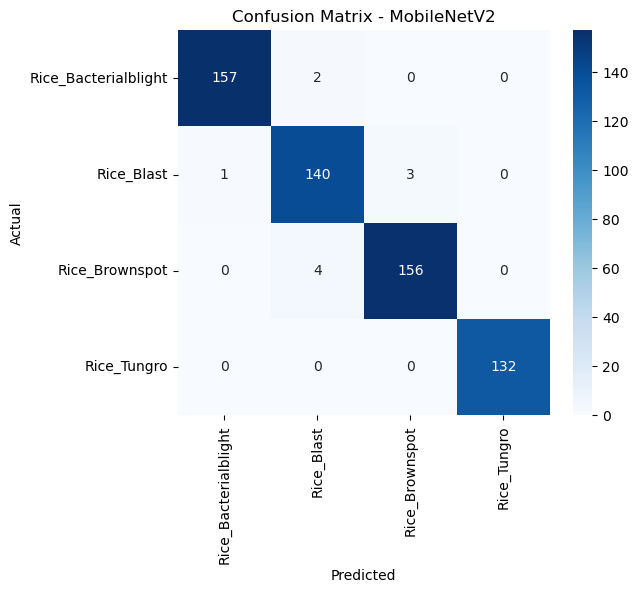

In [14]:
mob_acc, mob_report, y_true, y_pred = evaluate_model(model_mobilenet)

print("MobileNetV2 Accuracy:", mob_acc)
print(mob_report)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MobileNetV2")

plt.show()

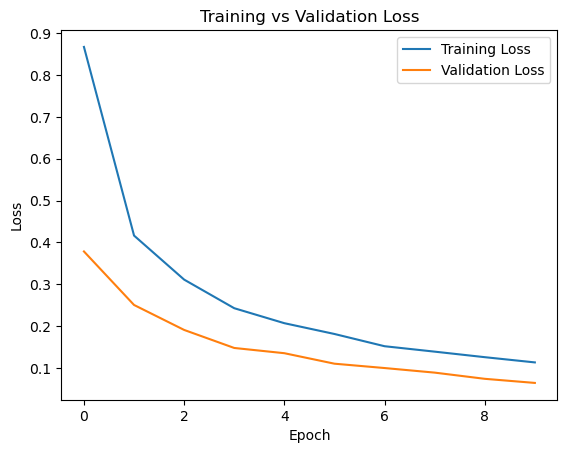

In [15]:
plt.plot(history_mobilenet.history['loss'], label='Training Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()